# plot_kyoto

Plots data from the kyoto model and compares it to condiono modelPlots data from the kyoto model

In [2]:
import matplotlib.pyplot as plt 
import numpy as np

import pandas as pd

## Reading kyoto data

In [4]:
condkyoto = pd.read_csv('HEIGHT      S0            S1_lat-60_lon120.txt',index_col="HEIGHT",sep="   ")

C:\Users\tedea\AppData\Local\Temp\ipykernel_7860\1730664181.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  condkyoto = pd.read_csv('HEIGHT      S0            S1_lat-60_lon120.txt',index_col="HEIGHT",sep="   ")


In [5]:
condkyoto

,S0,S1,S2
HEIGHT,,,
100.0,0.049388,9.646000e-06,1.826390e-04
110.0,0.241308,6.347590e-05,2.290960e-04
120.0,0.592739,1.176880e-04,1.102640e-04
130.0,1.247610,8.236170e-05,2.889520e-05
140.0,2.337430,5.177650e-05,8.657480e-06
150.0,3.847690,3.393770e-05,3.109770e-06
160.0,5.753010,2.320330e-05,1.276810e-06
170.0,7.988640,1.626250e-05,5.740880e-07
180.0,10.497300,1.159810e-05,2.764800e-07


### ploting kyoto model

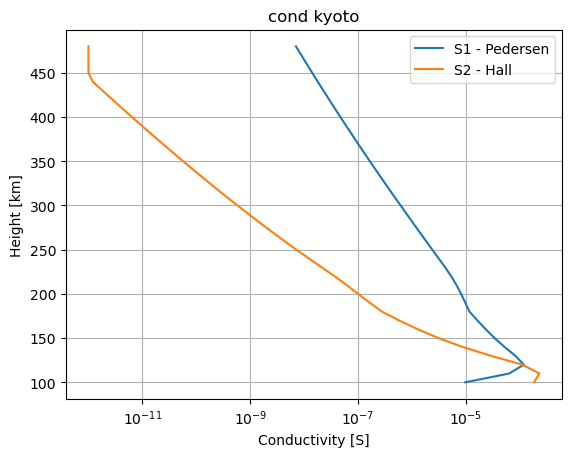

In [7]:
#plt.semilogx(condkyoto['S0'],condkyoto.index.get_level_values('HEIGHT').unique(),label="S0 - Paralela")
plt.semilogx(condkyoto["S1"],condkyoto.index.get_level_values('HEIGHT').unique(),label="S1 - Pedersen")
plt.plot(condkyoto["S2"],condkyoto.index.get_level_values('HEIGHT').unique(),label="S2 - Hall")

plt.xlabel('Conductivity [S]')
plt.ylabel("Height [km]")
plt.title("cond kyoto")

plt.legend()
plt.grid()

## Reading condiono data 

In [9]:
hall = pd.read_csv("Condutividade_de_Hall.csv")
hall

,ht,lat,lon,time,0
0,100.0,-80.0,0.0,0 days 00:00:00,0.000119
1,100.0,-80.0,0.0,0 days 00:15:00,0.000119
2,100.0,-80.0,0.0,0 days 00:30:00,0.000119
3,100.0,-80.0,0.0,0 days 00:45:00,0.000119
4,100.0,-80.0,0.0,0 days 01:00:00,0.000120
...,...,...,...,...,...
587515,480.0,80.0,340.0,0 days 22:45:00,0.000265
587516,480.0,80.0,340.0,0 days 23:00:00,0.000268
587517,480.0,80.0,340.0,0 days 23:15:00,0.000270
587518,480.0,80.0,340.0,0 days 23:30:00,0.000273


In [10]:
pedersen = pd.read_csv("Condutividade_de_Pedersen.csv")
pedersen

,ht,lat,lon,time,0
0,100.0,-80.0,0.0,0 days 00:00:00,1.227699e-07
1,100.0,-80.0,0.0,0 days 00:15:00,1.229439e-07
2,100.0,-80.0,0.0,0 days 00:30:00,1.232755e-07
3,100.0,-80.0,0.0,0 days 00:45:00,1.237615e-07
4,100.0,-80.0,0.0,0 days 01:00:00,1.243970e-07
...,...,...,...,...,...
587515,480.0,80.0,340.0,0 days 22:45:00,4.459838e-15
587516,480.0,80.0,340.0,0 days 23:00:00,4.535907e-15
587517,480.0,80.0,340.0,0 days 23:15:00,4.615148e-15
587518,480.0,80.0,340.0,0 days 23:30:00,4.695789e-15


### Going to Multiindex

In [12]:
def to_multiindex_conductivities(df):
    df.sort_values(['time','ht','lat','lon'],inplace = True)
    return df.set_index(['time','ht','lat','lon'])

In [13]:
hall = to_multiindex_conductivities(hall)
pedersen = to_multiindex_conductivities(pedersen)

In [14]:
 hall.index

MultiIndex([('0 days 00:00:00', 100.0, -80.0,   0.0),
            ('0 days 00:00:00', 100.0, -80.0,  20.0),
            ('0 days 00:00:00', 100.0, -80.0,  40.0),
            ('0 days 00:00:00', 100.0, -80.0,  60.0),
            ('0 days 00:00:00', 100.0, -80.0,  80.0),
            ('0 days 00:00:00', 100.0, -80.0, 100.0),
            ('0 days 00:00:00', 100.0, -80.0, 120.0),
            ('0 days 00:00:00', 100.0, -80.0, 140.0),
            ('0 days 00:00:00', 100.0, -80.0, 160.0),
            ('0 days 00:00:00', 100.0, -80.0, 180.0),
            ...
            ('0 days 23:45:00', 480.0,  80.0, 160.0),
            ('0 days 23:45:00', 480.0,  80.0, 180.0),
            ('0 days 23:45:00', 480.0,  80.0, 200.0),
            ('0 days 23:45:00', 480.0,  80.0, 220.0),
            ('0 days 23:45:00', 480.0,  80.0, 240.0),
            ('0 days 23:45:00', 480.0,  80.0, 260.0),
            ('0 days 23:45:00', 480.0,  80.0, 280.0),
            ('0 days 23:45:00', 480.0,  80.0, 300.0),
            

### separating a specific moment in time in a variable

In [16]:
plotpedersen = pedersen.loc["0 days 00:00:00",:,-60,0]
plothall = hall.loc["0 days 00:00:00",:,-60,0]

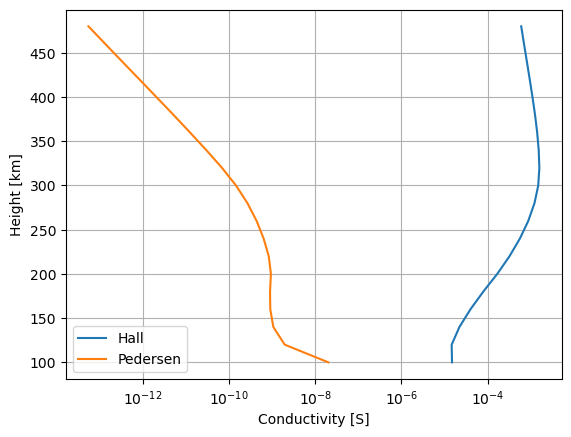

In [17]:
plt.plot(plothall,hall.index.get_level_values('ht').unique(),label="Hall")
plt.semilogx(plotpedersen,pedersen.index.get_level_values('ht').unique(),label= "Pedersen")
plt.xlabel('Conductivity [S]')
plt.ylabel("Height [km]")
plt.legend()
plt.grid()

In [18]:
height = hall.index.get_level_values('ht').unique().to_list()
condkyoto2 = condkyoto.loc[height]

In [19]:
condkyoto2

,S0,S1,S2
HEIGHT,,,
100.0,0.049388,9.646000e-06,1.826390e-04
120.0,0.592739,1.176880e-04,1.102640e-04
140.0,2.337430,5.177650e-05,8.657480e-06
160.0,5.753010,2.320330e-05,1.276810e-06
180.0,10.497300,1.159810e-05,2.764800e-07
200.0,18.086700,8.114360e-06,1.004280e-07
220.0,25.556100,5.308940e-06,3.644350e-08
240.0,31.194000,3.120230e-06,1.224770e-08
260.0,36.055400,1.803240e-06,4.241200e-09


## Plotting the Kyoto model

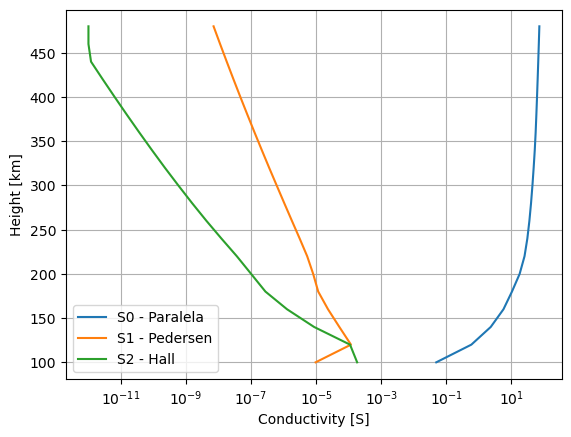

In [21]:
plt.semilogx(condkyoto2['S0'],condkyoto2.index.get_level_values('HEIGHT').unique(),label="S0 - Paralela")
plt.plot(condkyoto2["S1"],condkyoto2.index.get_level_values('HEIGHT').unique(),label="S1 - Pedersen")
plt.plot(condkyoto2["S2"],condkyoto2.index.get_level_values('HEIGHT').unique(),label="S2 - Hall")

plt.xlabel('Conductivity [S]')
plt.ylabel("Height [km]")

plt.legend()
plt.grid()

In [22]:
diff_pedersen = condkyoto2["S1"] - plotpedersen["0"]
diff_hall = condkyoto2["S1"] - plothall["0"]

In [23]:
diff_hall.to_csv("diff_hall.csv")
diff_hall.index,condkyoto2["S2"]

(Index([100.0, 120.0, 140.0, 160.0, 180.0, 200.0, 220.0, 240.0, 260.0, 280.0,
        300.0, 320.0, 340.0, 360.0, 380.0, 400.0, 420.0, 440.0, 460.0, 480.0],
       dtype='float64', name='HEIGHT'),
 HEIGHT
 100.0    1.826390e-04
 120.0    1.102640e-04
 140.0    8.657480e-06
 160.0    1.276810e-06
 180.0    2.764800e-07
 200.0    1.004280e-07
 220.0    3.644350e-08
 240.0    1.224770e-08
 260.0    4.241200e-09
 280.0    1.541060e-09
 300.0    5.813820e-10
 320.0    2.244720e-10
 340.0    8.956950e-11
 360.0    3.650890e-11
 380.0    1.517100e-11
 400.0    6.415120e-12
 420.0    2.756110e-12
 440.0    1.201740e-12
 460.0    1.000000e-12
 480.0    1.000000e-12
 Name: S2, dtype: float64)

In [24]:
pedersen

0
time            ht    lat   lon                
0 days 00:00:00 100.0 -80.0 0.0    1.227699e-07
                            20.0   1.295188e-07
                            40.0   1.432761e-07
                            60.0   1.633973e-07
                            80.0   1.890447e-07
...                                         ...
0 days 23:45:00 480.0  80.0 260.0  9.783716e-15
                            280.0  8.648465e-15
                            300.0  5.211839e-15
                            320.0  4.924690e-15
                            340.0  4.776177e-15

[587520 rows x 1 columns]

## Plotting both models

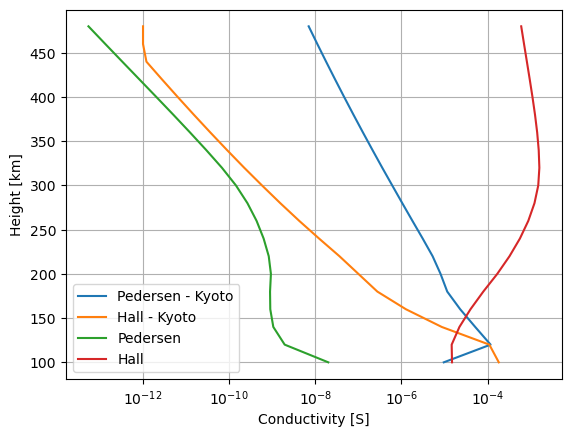

In [26]:
#plt.semilogx(diff_hall,diff_hall.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Hall")
#plt.plot(diff_pedersen,diff_pedersen.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Pedersen")
h = 4300
plt.plot(condkyoto2["S1"].loc[:h],condkyoto2.loc[:h].index.get_level_values('HEIGHT').unique(),label="Pedersen - Kyoto")
plt.plot(condkyoto2["S2"].loc[:h],condkyoto2.loc[:h].index.get_level_values('HEIGHT').unique(),label="Hall - Kyoto")

plt.semilogx(plotpedersen.loc[:h],pedersen.loc["0 days 00:00:00",:h,:,:].index.get_level_values('ht').unique(),label= "Pedersen")
plt.plot(plothall.loc[:h],hall.loc["0 days 00:00:00",:h,:,:].index.get_level_values('ht').unique(),label="Hall")

plt.xlabel('Conductivity [S]')
plt.ylabel("Height [km]")

plt.legend()
plt.grid()
plt.savefig("kyoto_CondutividadePedersen_lat-60_lon120_s20_01JAN2008_2.png")

comparing both models

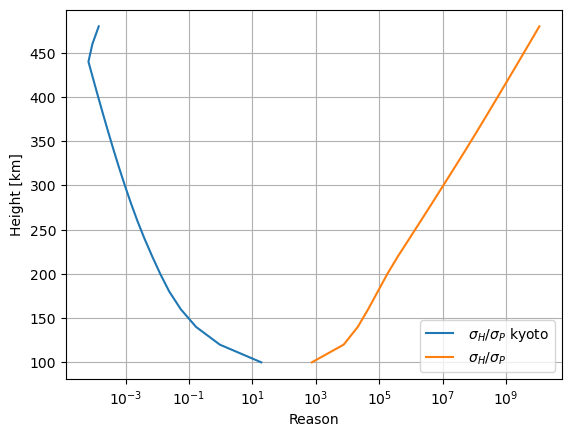

In [28]:
#plt.semilogx(diff_hall,diff_hall.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Hall")
#plt.plot(diff_pedersen,diff_pedersen.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Pedersen")
ht = condkyoto2.index.get_level_values('HEIGHT').unique()
plt.plot((condkyoto2["S2"]/condkyoto2["S1"]).loc[:h],condkyoto2.loc[:h].index.get_level_values('HEIGHT').unique(),label=" $\sigma_H$/$\sigma_P$ kyoto")

plt.semilogx((plothall/plotpedersen).loc[:h],pedersen.loc["0 days 00:00:00",:h,:,:].index.get_level_values('ht').unique(),label= " $\sigma_H$/$\sigma_P$")

plt.xlabel('Reason')
plt.ylabel("Height [km]")

plt.legend()
plt.grid()
plt.savefig("kyotoCondutividadePedersen_divididos_lat-60_lon120_s20_01JAN2008_2.png")

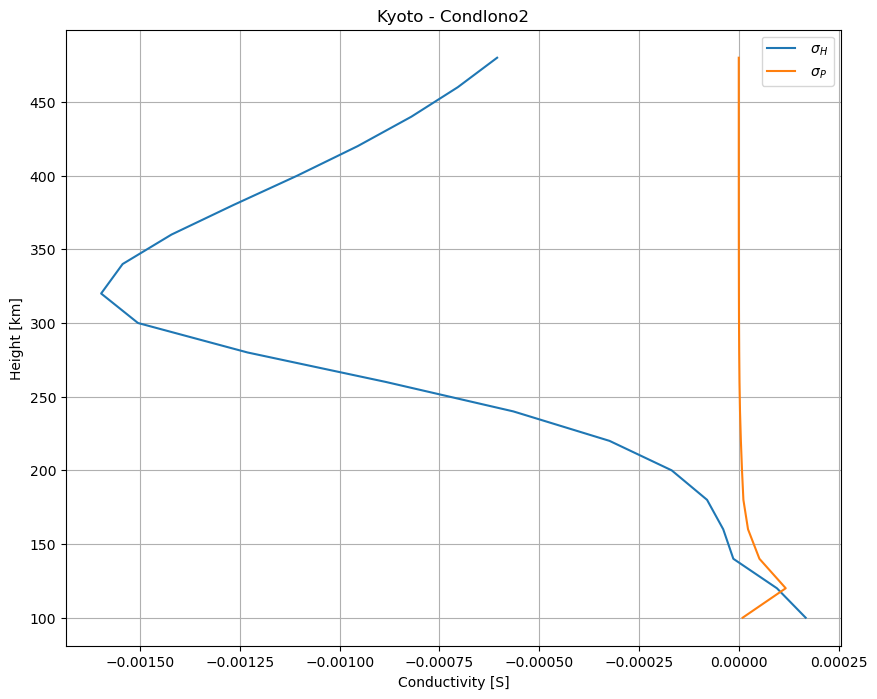

In [29]:
#plt.semilogx(diff_hall,diff_hall.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Hall")
#plt.plot(diff_pedersen,diff_pedersen.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Pedersen")
plt.figure(figsize = (10,8))
plt.plot(condkyoto2["S2"].loc[:h] - plothall['0'].loc[:h],condkyoto2.loc[:h].index.get_level_values('HEIGHT').unique(),label = " $\sigma_H$")
plt.plot(condkyoto2["S1"].loc[:h] - plotpedersen['0'].loc[:h],pedersen.loc["0 days 00:00:00",:h,:,:].index.get_level_values('ht').unique(), label = " $\sigma_P$")

plt.xlabel('Conductivity [S]')
plt.ylabel("Height [km]")

plt.title("Kyoto - CondIono2")
plt.legend()
plt.grid()
plt.savefig("kyoto-CondutividadePedersen_lat-60_lon120_s20_01JAN2008.png")

Text(0.5, 0, '$\\sigma_H$/$\\sigma_P$')

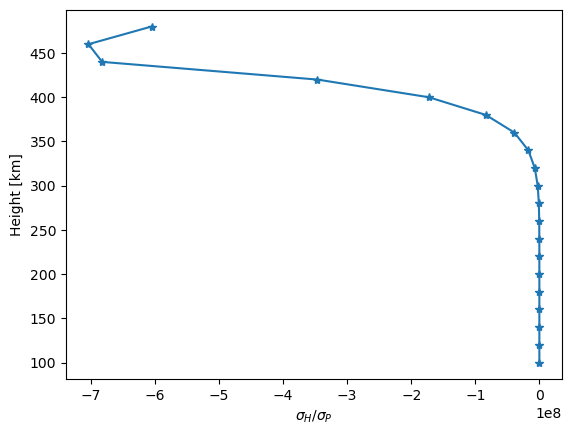

In [30]:
plt.plot(diff_hall/condkyoto2["S2"],height,'*-')
plt.ylabel("Height [km]")
plt.xlabel("$\sigma_H$/$\sigma_P$")

In [31]:
diff_hall/condkyoto2["S2"]

HEIGHT
100.0   -2.920743e-02
120.0    9.339848e-01
140.0    3.408796e+00
160.0   -1.329749e+01
180.0   -2.465626e+02
200.0   -1.593701e+03
220.0   -8.740560e+03
240.0   -4.586561e+04
260.0   -2.081477e+05
280.0   -7.981593e+05
300.0   -2.588479e+06
320.0   -7.116244e+06
340.0   -1.723464e+07
360.0   -3.893086e+07
380.0   -8.349211e+07
400.0   -1.724189e+08
420.0   -3.464860e+08
440.0   -6.825894e+08
460.0   -7.040511e+08
480.0   -6.054793e+08
dtype: float64

In [32]:
# #plt.plot(plothall['0']/condkyoto2["S2"],diff_hall.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono Hall")
# plt.plot(plotpedersen['0']/condkyoto2["S1"],diff_hall.index.get_level_values('HEIGHT').unique(),label="kyoto-condiono pedersen")
# plt.legend()

In [33]:
plotpedersen

,0
ht,
100.0,2.005060e-08
120.0,1.948255e-09
140.0,1.061131e-09
160.0,9.022369e-10
180.0,8.908698e-10
200.0,9.333548e-10
220.0,8.310679e-10
240.0,6.322524e-10
260.0,4.337020e-10


## Calculating height integrated conductivities

In [35]:
import numpy as np
import scipy.integrate as scp

In [36]:
def calc_height_integrtated_conductivity(values):
    #list to be filled with height intratade values. cada linha é numa latitude específica e coluna uma longitude
    print(values, type(values))
    print(values.index.get_level_values('ht').unique())    
    heightintegratedcond = scp.trapz(values,values.index.get_level_values('ht').unique())

    return heightintegratedcond 

In [37]:
plothall.loc[:480]['0'],scp.trapz(plotpedersen.loc[:480]["0"],plothall.loc[:480].index.get_level_values('ht').unique()*1000) #multiplica por 1000 pq altura está em km

(ht
 100.0    0.000015
 120.0    0.000015
 140.0    0.000022
 160.0    0.000040
 180.0    0.000080
 200.0    0.000168
 220.0    0.000324
 240.0    0.000565
 260.0    0.000885
 280.0    0.001231
 300.0    0.001506
 320.0    0.001598
 340.0    0.001544
 360.0    0.001421
 380.0    0.001267
 400.0    0.001106
 420.0    0.000955
 440.0    0.000820
 460.0    0.000704
 480.0    0.000605
 Name: 0, dtype: float64,
 0.00036373543514339534)

Calculating Height integrated conductivities using the scipy and numpy libraries for the trapesoid method of integration.

In [39]:
import scipy.integrate as scp

In [40]:
scp.trapz(condkyoto2['S1'],condkyoto2['S2'].index.get_level_values("HEIGHT")*1000)

4.599696295399999

In [41]:
np.trapz(condkyoto2['S2'],condkyoto2['S2'].index.get_level_values("HEIGHT")*1000)

4.2390026087274